In [ ]:
import os
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scvi
import scanpy.external as sce
import squidpy as sq

/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
spatial_adata = sc.read_h5ad("./st_QC_normed_BC_project_PsoADLP.h5")

In [ ]:
print('Number of NL patients: ', len(
        spatial_adata.obs.loc[spatial_adata.obs['biopsy_type'] == 'NON LESIONAL', 'patient'].unique()))
print('Number of AD patients: ', len(
    spatial_adata.obs.loc[(spatial_adata.obs['DISEASE'] == 'AD') & (
        spatial_adata.obs['biopsy_type'] != 'NON LESIONAL'), 'patient'].unique()))
print('Number of Pso patients: ', len(
    spatial_adata.obs.loc[(spatial_adata.obs['DISEASE'] == 'Pso') & (
        spatial_adata.obs['biopsy_type'] != 'NON LESIONAL'), 'patient'].unique()))
print('Number of LP patients: ', len(
    spatial_adata.obs.loc[(spatial_adata.obs['DISEASE'] == 'LP') & (
        spatial_adata.obs['biopsy_type'] != 'NON LESIONAL'), 'patient'].unique()))

In [ ]:
def prepare_data(adata):
    # remove JUNCTION
    adata.obs["tissue_layer"] = adata.obs["tissue_layer"].astype(str)
    mask = adata.obs["tissue_layer"] == "JUNCTION"
    mask_middle_epidermis = adata.obs["middle EPIDERMIS"] == 1
    mask_basal_epidermis = adata.obs["basal EPIDERMIS"] == 1
    mask_upper_epidermis = adata.obs["upper EPIDERMIS"] == 1
    mask_dermis_1 = adata.obs["DERdepth1"] == 1
    mask_dermis_2 = adata.obs["DERdepth2"] == 1
    adata.obs.loc[mask & mask_middle_epidermis, "tissue_layer"] = "middle EPIDERMIS"
    adata.obs.loc[mask & mask_basal_epidermis, "tissue_layer"] = "basal EPIDERMIS"
    adata.obs.loc[mask & mask_upper_epidermis, "tissue_layer"] = "upper EPIDERMIS"
    adata.obs.loc[mask & mask_dermis_1, "tissue_layer"] = "DERdepth1"
    adata.obs.loc[mask & mask_dermis_2, "tissue_layer"] = "DERdepth2"
    mask = adata.obs["tissue_layer"] == "JUNCTION"
    adata.obs.loc[mask, "tissue_layer"] = 'basal EPIDERMIS'
    adata.obs["tissue_layer"] = adata.obs["tissue_layer"].astype('category')
    adata.obs["tissue_layer"] = adata.obs["tissue_layer"].cat.remove_unused_categories()


    # Rename falsely labeled spots
    if np.any((adata.obs['basal EPIDERMIS'] == 1) & (adata.obs['DERdepth1'] == 1)):
        adata.obs.loc[
            (adata.obs['basal EPIDERMIS'] == 1) & (adata.obs['DERdepth1'] == 1), 'basal EPIDERMIS'] = [0, 0]

    return adata

In [ ]:
spatial_adata = prepare_data(spatial_adata)

# Subset to lesional AD and PSO only

In [ ]:
spatial_adata_ad_pso = spatial_adata[(spatial_adata.obs["DISEASE"].isin(["AD", "Pso"])) & (spatial_adata.obs["biopsy_type"] == "LESIONAL"),].copy()

In [ ]:
print("P21093_21L008961" in spatial_adata_ad_pso.obs["sample"].unique())
print("P16357_1015" in spatial_adata_ad_pso.obs["sample"].unique())

In [ ]:
spatial_adata_ad_pso.obs_names_make_unique()

In [ ]:
path_to_spaceranger_output = "./spatial/Haniffa"
anndatas = []
for i in range(1,9):
    if i in [2,6,7]:
        stage = "IA"
    elif i in [1, 5]:
        continue
    elif i in [3,4,8]:
        stage = "IB"
    else:
        raise ValueError("Wrong id")
    adata = sq.read.visium(os.path.join(path_to_spaceranger_output, f"CTCL{i}_spaceranger_output"))
    adata.var_names_make_unique()
    adata = adata[adata.obs['in_tissue'] == 1].copy()

    # Store the original library_id before modifying
    original_library_id = list(adata.uns['spatial'].keys())[0]
    sample_name = f"CTCL_{i}"
    
    # Rename the spatial dictionary key to match your sample name
    adata.uns['spatial'][sample_name] = adata.uns['spatial'].pop(original_library_id)
    
    adata.obs["stage"] = stage
    adata.obs_names = [f"{sample_name}_{barcode}" for barcode in adata.obs_names]
    adata.obs["disease"] = "MF"
    adata.obs["sample"] = sample_name
    adata.obs["library_id"] = sample_name 
    anndatas.append(adata)

In [ ]:
adata_mf = ad.concat(anndatas, join="outer", uns_merge="unique")

In [ ]:
adata_mf.var["mt"] = adata_mf.var_names.str.startswith("MT-")
# ribosomal genes
adata_mf.var["ribo"] = adata_mf.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_mf.var["hb"] = adata_mf.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata_mf, qc_vars=["mt", "ribo", "hb"],inplace=True)

In [ ]:
print(f"Number of MF patients: {len(adata_mf.obs["sample"].unique())}")

In [ ]:
sc.pl.violin(spatial_adata_ad_pso, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [ ]:
sc.pl.violin(
    adata_mf,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
sc.pl.scatter(spatial_adata_ad_pso, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
sc.pl.scatter(adata_mf, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [22]:
def normalize_data(adata: sc.AnnData) -> sc.AnnData:
    adata2 = adata.copy()
    if "counts" not in adata2.layers:
        adata2.layers["counts"] = adata2.X.copy()
    sc.pp.normalize_total(adata2, target_sum=1e4)
    # Logarithmize the data
    sc.pp.log1p(adata2)
    adata2.raw = adata2.copy()
    return adata2

In [23]:
adata_mf = normalize_data(adata_mf)
spatial_adata_ad_pso = normalize_data(spatial_adata_ad_pso)

/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [24]:
adata_mf_cleaned = adata_mf[(adata_mf.obs["total_counts"] > 200) & (adata_mf.obs["total_counts"] < 500_000) & (adata_mf.obs["n_genes_by_counts"] > 100) & (adata_mf.obs["pct_counts_mt"] < 25) & (adata_mf.obs["in_tissue"] == 1),].copy()

In [25]:
adata_ad_pso_cleaned = spatial_adata_ad_pso[(spatial_adata_ad_pso.obs["total_counts"] > 50) & (spatial_adata_ad_pso.obs["total_counts"] < 500_000) & (spatial_adata_ad_pso.obs["n_genes_by_counts"] > 30) & (spatial_adata_ad_pso.obs["pct_counts_mt"] < 25) & (spatial_adata_ad_pso.obs["in_tissue"] == 1)].copy()

In [26]:
# After loading your data
print("MF median genes per spot:", adata_mf_cleaned.obs['n_genes_by_counts'].median())
print("AD/PSO median genes per spot:", adata_ad_pso_cleaned.obs['n_genes_by_counts'].median())

print("MF median UMIs per spot:", adata_mf_cleaned.obs['total_counts'].median())
print("AD/PSO median UMIs per spot:", adata_ad_pso_cleaned.obs['total_counts'].median())

MF median genes per spot: 4927.0
AD/PSO median genes per spot: 891.0
MF median UMIs per spot: 9555.0
AD/PSO median UMIs per spot: 1546.0


In [31]:
del spatial_adata
del adata_mf
del spatial_adata_ad_pso

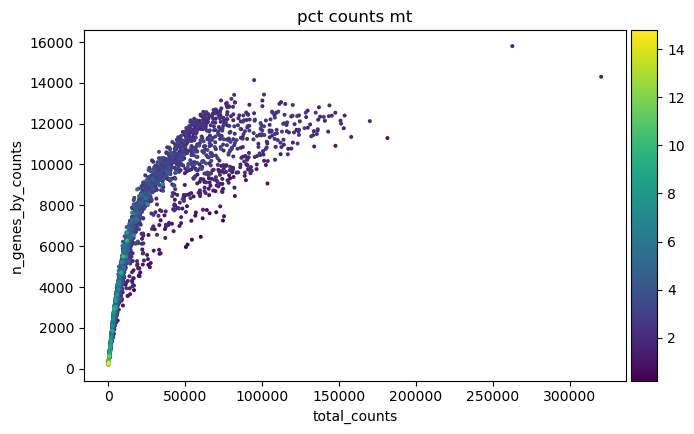

In [32]:
sc.pl.scatter(adata_mf_cleaned, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [33]:
# Check for overlapping genes
genes_mf = set(adata_mf_cleaned.var_names)
genes_psor_eczema = set(adata_ad_pso_cleaned.var_names)

# 2. Calculate the intersection
shared_genes = genes_mf.intersection(genes_psor_eczema)

# 3. Calculate the number of lost/unique genes
num_mf_only = len(genes_mf - shared_genes)
num_psor_eczema_only = len(genes_psor_eczema - shared_genes)

print(f"Shared genes: {len(shared_genes)}")
                           

Shared genes: 15874


In [36]:
adata_mf_cleaned.obs["tissue_layer"] = "Unknown"
adata_mf_cleaned.obs["biopsy_type"] = "LESIONAL"
adata_mf_cleaned.obs["DISEASE"] = "MF"
adata_mf_cleaned.obs["patient"] = adata_mf_cleaned.obs["sample"]
adata_ad_pso_cleaned.obs["stage"] = "unknown"

common_genes = adata_mf_cleaned.var_names.intersection(adata_ad_pso_cleaned.var_names)
print(f"Common genes: {len(common_genes)}")
    
# Subset to common genes
adata_combined = ad.concat([adata_ad_pso_cleaned, adata_mf_cleaned], join='inner', label='dataset_batch',
                                     keys=['Psoriasis_Eczema', 'MF'], uns_merge="unique")
adata_combined.obs["tissue_layer"] = adata_combined.obs["tissue_layer"].astype("category")
print(adata_combined.n_vars)
print(adata_combined.n_obs)

Common genes: 15874
15874
30365


In [37]:
adata_combined.obs["patient"].unique()

[1, 2, 5, 8, 10, ..., 'CTCL_3', 'CTCL_4', 'CTCL_6', 'CTCL_7', 'CTCL_8']
Length: 24
Categories (24, object): [1, 2, 5, 8, ..., 'CTCL_4', 'CTCL_6', 'CTCL_7', 'CTCL_8']

In [ ]:
from datetime import datetime
adata_combined.obs["patient"] = adata_combined.obs["patient"].astype("category")
today = datetime.now().strftime("%Y_%m_%d")

In [42]:
# Use HVGs only for scVI
sc.pp.highly_variable_genes(adata_combined, flavor="cell_ranger", n_top_genes=4000, batch_key="sample")
adata_scvi = adata_combined[:, adata_combined.var.highly_variable].copy()

In [44]:
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key="sample")

In [ ]:
scvi_ref = scvi.model.SCVI(adata_scvi, n_layers=2, n_latent=30, n_hidden=128, dropout_rate=0.1, gene_likelihood="nb", use_layer_norm="both", use_batch_norm="none")
scvi_ref.train(
 max_epochs=400,
    batch_size=128,
    early_stopping=True,
    early_stopping_patience=15,
    train_size=0.9,                    # Add validation set
    validation_size=0.1,
    check_val_every_n_epoch=5,         # Monitor validation
    plan_kwargs={
        'lr': 1e-3,                    # ✅ Start with your preferred higher LR
        'weight_decay': 1e-6,
        'reduce_lr_on_plateau': True,  # ✅ Add LR scheduling
        'lr_patience': 10,             # Reduce LR if no improvement for 10 epochs
        'lr_factor': 0.6,              # Reduce to 60% of current LR
        'lr_scheduler_metric': 'elbo_validation'
    }
)

/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/li ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/li ...
/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_datal

Epoch 364/400:  91%|█████████ | 364/400 [27:37<02:43,  4.55s/it, v_num=1, train_loss=1.44e+3]
Monitored metric elbo_validation did not improve in the last 15 records. Best score: 1441.656. Signaling Trainer to stop.


In [46]:
train_elbo = scvi_ref.history["elbo_train"]
val_elbo = scvi_ref.history["elbo_validation"]

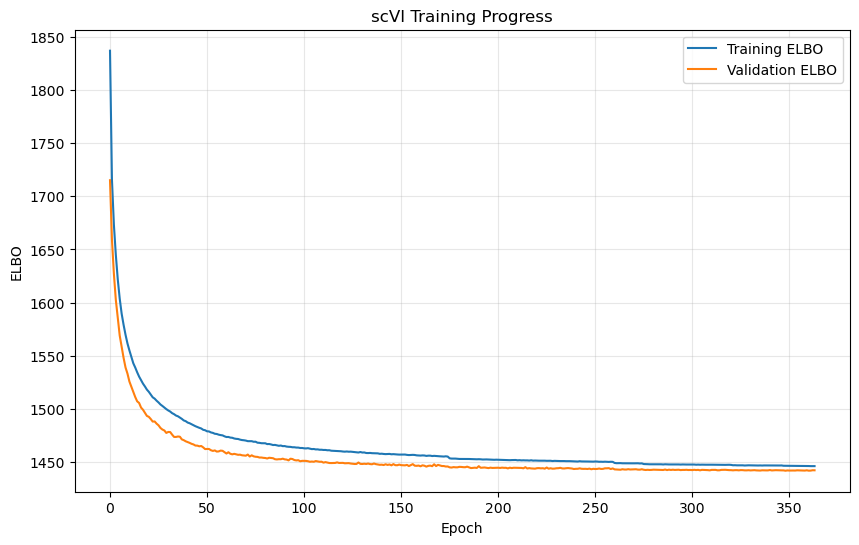

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(scvi_ref.history["elbo_train"], label='Training ELBO')
plt.plot(scvi_ref.history["elbo_validation"], label='Validation ELBO')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.title('scVI Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [48]:
adata_combined.obsm["X_scVI"] = scvi_ref.get_latent_representation()

In [49]:
sc.pp.neighbors(adata_combined, use_rep="X_scVI")
sc.tl.umap(adata_combined)

In [50]:
adata_combined.obs.columns

Index(['sample', 'patient', 'in_tissue', 'array_row', 'array_col', 'DISEASE',
       'library_id', 'biopsy_type', 'tissue_layer', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'stage',
       'dataset_batch'],
      dtype='object')

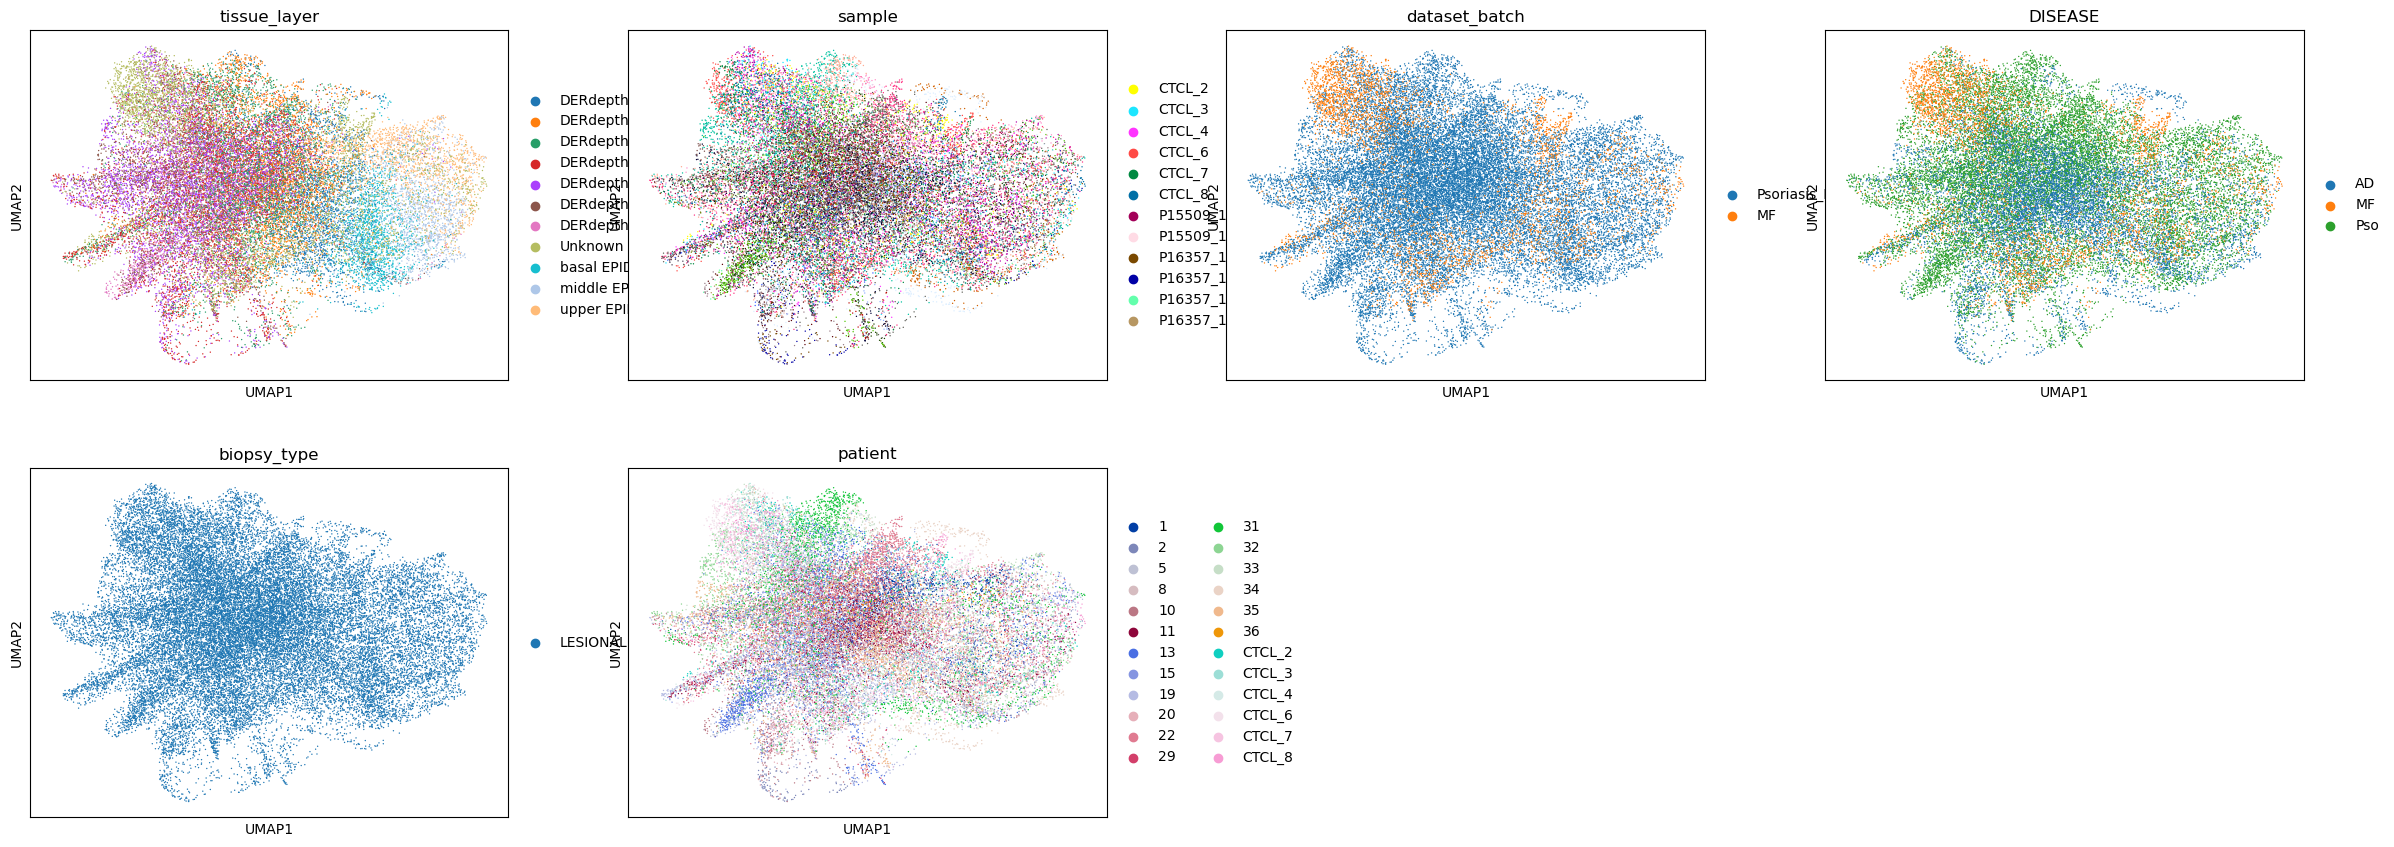

In [52]:
sc.pl.umap(adata_combined, color=["tissue_layer", "sample", "dataset_batch", "DISEASE", "biopsy_type", "patient"])

In [ ]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_ref,
    unlabeled_category="Unknown",  # Make sure this matches your data
    labels_key="tissue_layer"   # Your layer annotation column
)

# Train with proper hyperparameters
print("\nStarting training...")
scanvi_model.train(
    max_epochs=200,                    # Sufficient epochs
    batch_size=128,
    early_stopping=True,               # Stop when converged
    early_stopping_patience=20,
    early_stopping_monitor='validation_classification_loss', # Wait 20 epochs before stopping
    check_val_every_n_epoch=5,         # Check validation every 5 epochs
    train_size=0.8,                    # 90% training, 10% validation
    validation_size=0.2,
    plan_kwargs={
        'lr': 1e-4,                    # Match your scVI learning rate
        'weight_decay': 1e-6,          # Match your scVI weight decay
        'reduce_lr_on_plateau': True,  # Reduce LR when validation plateaus
        'lr_patience': 10,             # Wait 10 epochs before reducing LR
        'lr_factor': 0.6,              # Reduce LR by 40%
        'lr_scheduler_metric': 'validation_classification_loss'  # Use validation ELBO
    }
)



Starting training...
INFO     Training for 200 epochs.                                                                                  


/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/li ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/li ...
/home/icb/martin.meinel/miniconda3/envs/pbeqtl_39/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_datal

Epoch 44/200:  22%|██▏       | 44/200 [07:05<25:10,  9.68s/it, v_num=1, train_loss=1.47e+3]
Monitored metric validation_classification_loss did not improve in the last 20 records. Best score: 1.120. Signaling Trainer to stop.


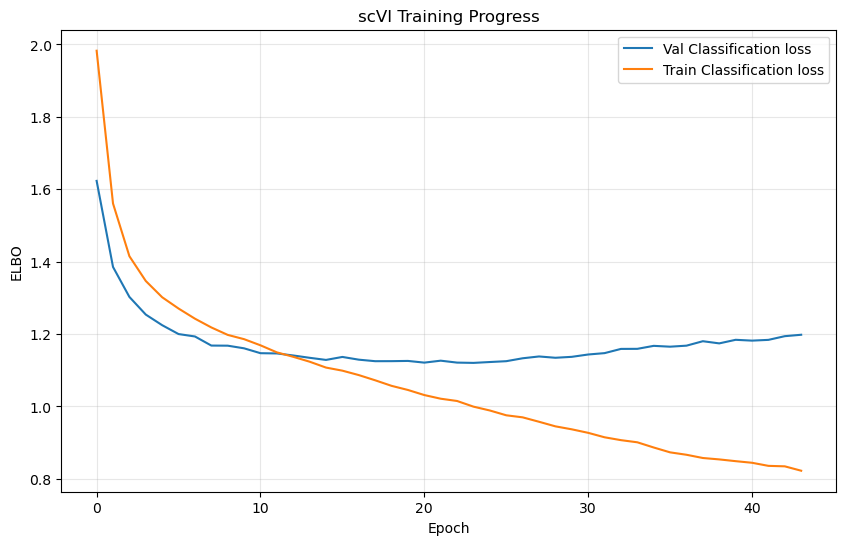

In [54]:
plt.figure(figsize=(10, 6))
# plt.plot(scanvi_model.history["elbo_train"], label='Training ELBO')
# plt.plot(scanvi_model.history["train_loss"], label='Train loss')
# plt.plot(scanvi_model.history["reconstruction_loss_train"], label='Reconstruction')
plt.plot(scanvi_model.history["validation_classification_loss"], label='Val Classification loss')
plt.plot(scanvi_model.history["train_classification_loss"], label='Train Classification loss')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.title('scVI Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


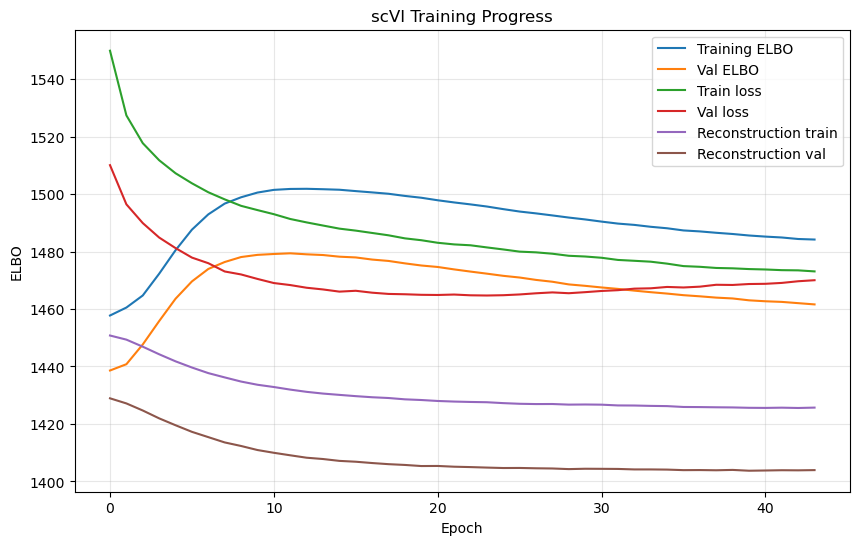

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(scanvi_model.history["elbo_train"], label='Training ELBO')
plt.plot(scanvi_model.history["elbo_validation"], label='Val ELBO')
plt.plot(scanvi_model.history["train_loss"], label='Train loss')
plt.plot(scanvi_model.history["validation_loss"], label='Val loss')
plt.plot(scanvi_model.history["reconstruction_loss_train"], label='Reconstruction train')
plt.plot(scanvi_model.history["reconstruction_loss_validation"], label='Reconstruction val')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.title('scVI Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [56]:
SCANVI_LATENT_KEY = "X_scANVI"
adata_combined.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation()

In [57]:
sc.pp.neighbors(adata_combined, use_rep="X_scANVI")
sc.tl.umap(adata_combined)

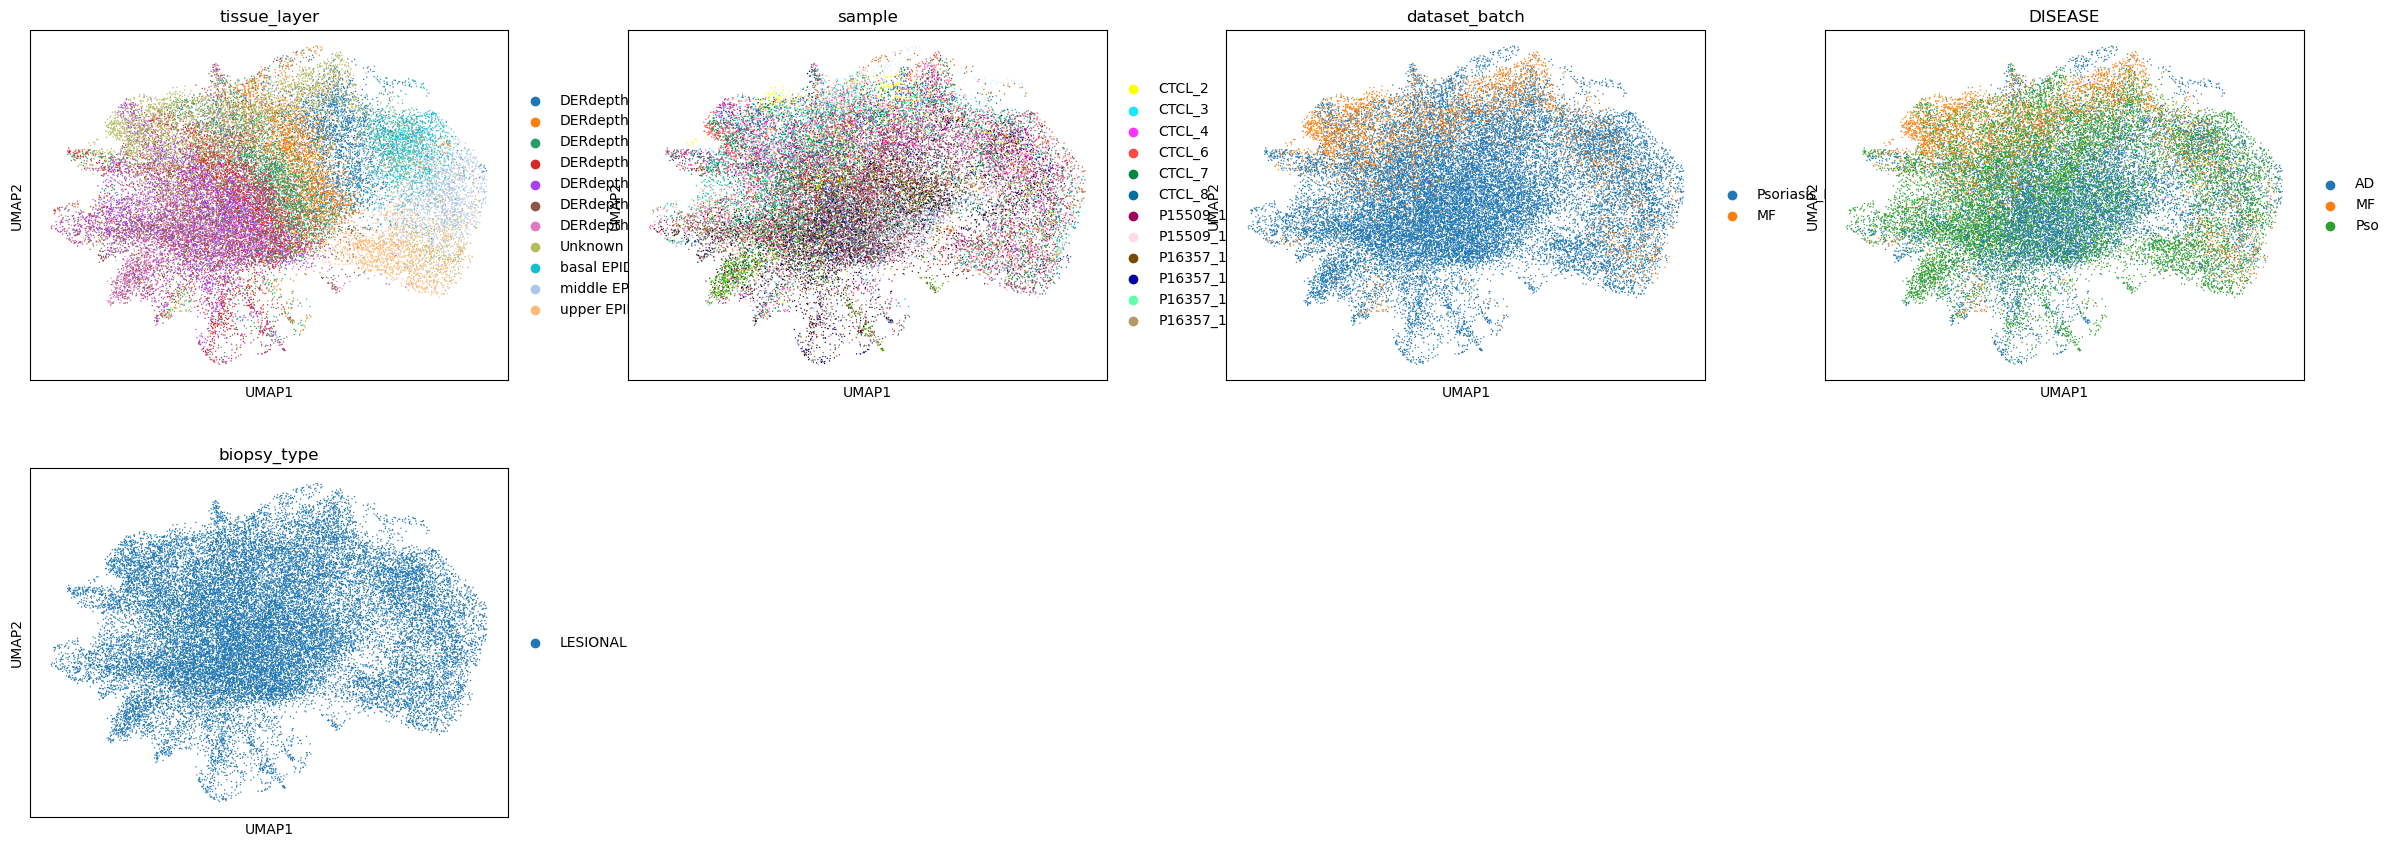

In [58]:
sc.pl.umap(adata_combined, color=["tissue_layer", "sample", "dataset_batch", "DISEASE", "biopsy_type"])

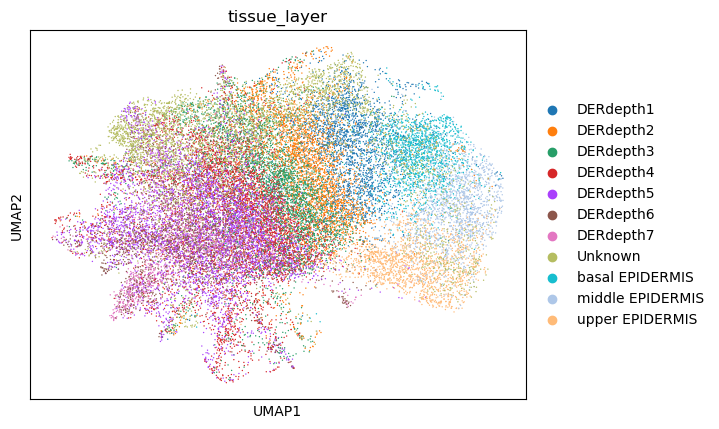

In [59]:
sc.pl.umap(adata_combined, color="tissue_layer")

In [60]:
predictions = scanvi_model.predict()

In [61]:
dataset_mask = adata_combined.obs["dataset_batch"] != "MF"

In [62]:
ground_truth = adata_combined.obs.loc[dataset_mask, "tissue_layer"].values

# Coarse predictions

In [66]:
adata_combined.obs["predicted_tissue_layer"] = scanvi_model.predict()
adata_combined.obs["predictions_probabilities"] = scanvi_model.predict(soft=True).max(1).values

In [67]:
mf_mask = adata_combined.obs["dataset_batch"] == "MF"
adata_combined.obs.loc[mf_mask, "tissue_layer"] = adata_combined.obs.loc[mf_mask, "predicted_tissue_layer"]

In [70]:
adata_combined.obs["tissue_layer_coarse"] = np.where(adata_combined.obs["tissue_layer"].str.startswith("DER"), "Dermis", "Epidermis")
adata_combined.obs["prediced_tissue_layer_coarse"] = np.where(adata_combined.obs["predicted_tissue_layer"].str.startswith("DER"), "Dermis", "Epidermis")

In [71]:
print((adata_combined.obs.loc[dataset_mask, "tissue_layer_coarse"].values == adata_combined.obs.loc[dataset_mask, "prediced_tissue_layer_coarse"].values).mean())

0.9854238301689341


In [72]:
adata_combined.obs.head()

,sample,patient,in_tissue,array_row,array_col,DISEASE,library_id,biopsy_type,tissue_layer,n_genes_by_counts,...,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,stage,dataset_batch,predicted_tissue_layer,predictions_probabilities,tissue_layer_coarse,prediced_tissue_layer_coarse
AAACTGCTGGCTCCAA,P15509_1003,1,1,45,67,Pso,P15509_1003_3,LESIONAL,DERdepth1,349,...,12.314225,0.0,0.000000,0.000000,unknown,Psoriasis_Eczema,DERdepth2,0.418560,Dermis,Dermis
AAAGGGATGTAGCAAG,P15509_1003,1,1,24,62,Pso,P15509_1003_3,LESIONAL,DERdepth5,102,...,10.169491,0.0,0.000000,0.000000,unknown,Psoriasis_Eczema,DERdepth5,0.499112,Dermis,Dermis
AAATACCTATAAGCAT,P15509_1003,1,1,47,69,Pso,P15509_1003_3,LESIONAL,DERdepth1,809,...,13.941221,1.0,0.693147,0.075358,unknown,Psoriasis_Eczema,DERdepth1,0.636918,Dermis,Dermis
AAATAGGGTGCTATTG,P15509_1003,1,1,53,79,Pso,P15509_1003_3,LESIONAL,middle EPIDERMIS,5796,...,11.224015,2.0,1.098612,0.007156,unknown,Psoriasis_Eczema,basal EPIDERMIS,0.568472,Epidermis,Epidermis
AAATCGTGTACCACAA,P15509_1003,1,1,44,56,Pso,P15509_1003_3,LESIONAL,DERdepth1,514,...,15.006640,0.0,0.000000,0.000000,unknown,Psoriasis_Eczema,DERdepth1,0.904751,Dermis,Dermis


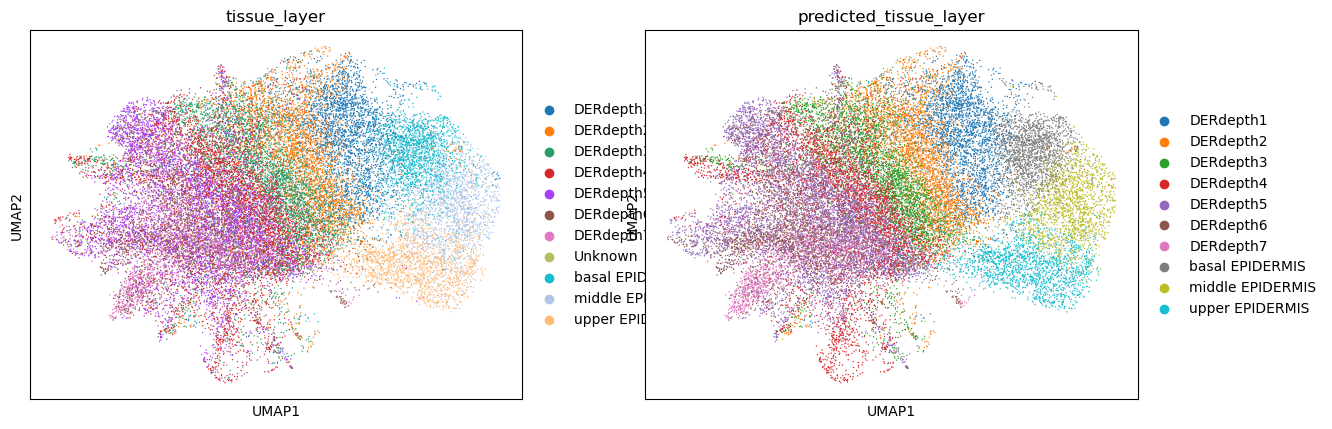

In [73]:
sc.pl.umap(adata_combined, color=["tissue_layer", "predicted_tissue_layer"])

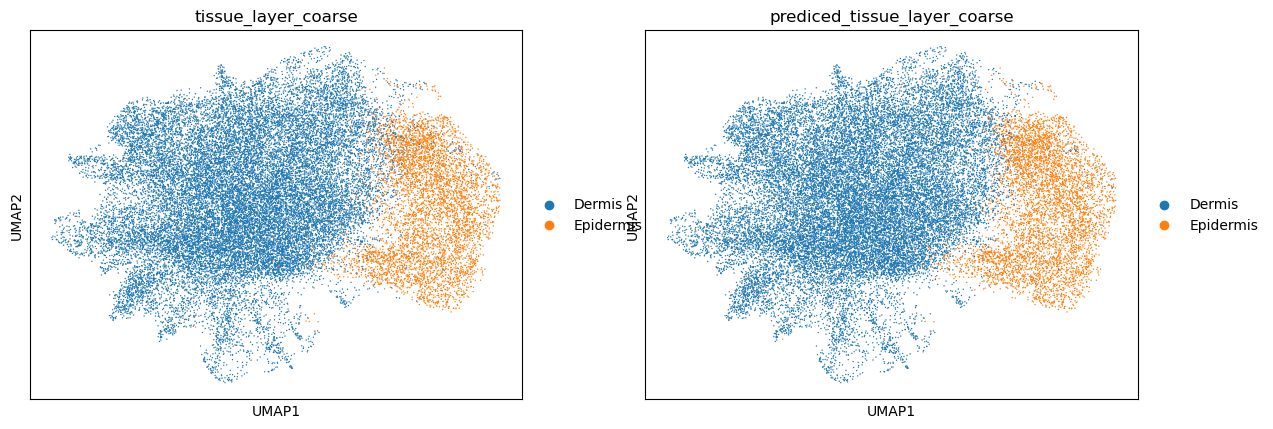

In [75]:
sc.pl.umap(adata_combined, color=["tissue_layer_coarse", "prediced_tissue_layer_coarse"])

In [83]:
pseudobulk_patient_tissue = adata_combined.to_df(layer="counts").groupby([adata_combined.obs["patient"], adata_combined.obs["tissue_layer_coarse"]]).sum().T

In [85]:
len(pseudobulk_patient_tissue.columns)

48

In [87]:
pseudobulk_patient_tissue.columns = pseudobulk_patient_tissue.columns.get_level_values(0).astype(str) + "_" + pseudobulk_patient_tissue.columns.get_level_values(1).astype(str)

In [88]:
pseudobulk_patient_tissue

,1_Dermis,1_Epidermis,2_Dermis,2_Epidermis,5_Dermis,5_Epidermis,8_Dermis,8_Epidermis,10_Dermis,10_Epidermis,...,CTCL_3_Dermis,CTCL_3_Epidermis,CTCL_4_Dermis,CTCL_4_Epidermis,CTCL_6_Dermis,CTCL_6_Epidermis,CTCL_7_Dermis,CTCL_7_Epidermis,CTCL_8_Dermis,CTCL_8_Epidermis
SAMD11,0.0,5.0,4.0,10.0,0.0,1.0,6.0,2.0,2.0,2.0,...,31.0,1.0,57.0,14.0,89.0,12.0,40.0,4.0,69.0,14.0
NOC2L,77.0,864.0,201.0,417.0,70.0,77.0,226.0,362.0,127.0,259.0,...,329.0,257.0,504.0,889.0,656.0,704.0,280.0,106.0,243.0,273.0
KLHL17,13.0,108.0,11.0,34.0,3.0,15.0,43.0,82.0,19.0,39.0,...,49.0,53.0,133.0,146.0,229.0,118.0,79.0,26.0,102.0,60.0
PLEKHN1,33.0,422.0,80.0,371.0,45.0,221.0,173.0,324.0,71.0,242.0,...,58.0,492.0,428.0,1566.0,276.0,988.0,163.0,292.0,116.0,443.0
PERM1,0.0,2.0,0.0,3.0,1.0,2.0,0.0,5.0,0.0,2.0,...,16.0,6.0,27.0,16.0,56.0,11.0,34.0,6.0,32.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,161.0,952.0,3020.0,2159.0,847.0,534.0,817.0,954.0,1959.0,1113.0,...,13343.0,4838.0,20370.0,21212.0,27729.0,14030.0,18072.0,5588.0,25248.0,11179.0
MT-ND4,7031.0,57287.0,44325.0,63939.0,12693.0,13725.0,20292.0,28886.0,29078.0,35214.0,...,13507.0,5247.0,23415.0,30948.0,32072.0,17468.0,16790.0,5279.0,25477.0,10885.0
MT-ND5,452.0,2931.0,7410.0,7200.0,2988.0,2287.0,2733.0,2822.0,5579.0,3061.0,...,7098.0,1639.0,9273.0,8248.0,14474.0,5656.0,9156.0,1975.0,16149.0,4501.0
MT-ND6,5.0,125.0,232.0,227.0,107.0,72.0,109.0,117.0,114.0,66.0,...,6219.0,937.0,7977.0,6304.0,10804.0,3863.0,6372.0,1607.0,10066.0,3132.0


In [106]:
# Just get unique patient-tissue-disease combinations
colData = adata_combined.obs[["patient", "tissue_layer_coarse", "DISEASE"]].drop_duplicates()
colData.set_index(colData["patient"].astype(str)+"_"+colData["tissue_layer_coarse"].astype(str), inplace=True)

In [109]:
colData = colData.loc[pseudobulk_patient_tissue.columns]

In [112]:
colData.to_csv(f"/lustre/groups/cbm01/datasets/martin.meinel/Safari/spatial/pseudobulk/colData_patient_coarse_layer{today}.csv")
pseudobulk_patient_tissue.to_csv(f"/lustre/groups/cbm01/datasets/martin.meinel/Safari/spatial/pseudobulk/pseudobulks_patient_coarse_layer_{today}.csv")

# H&E images

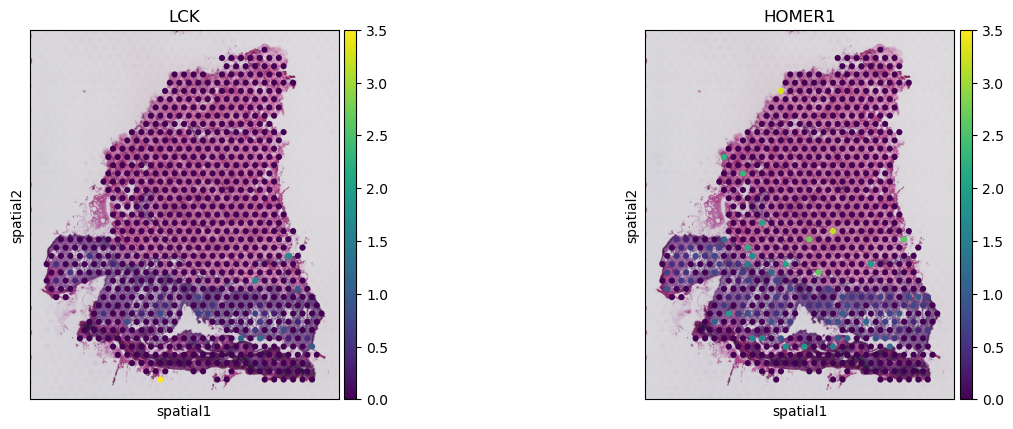

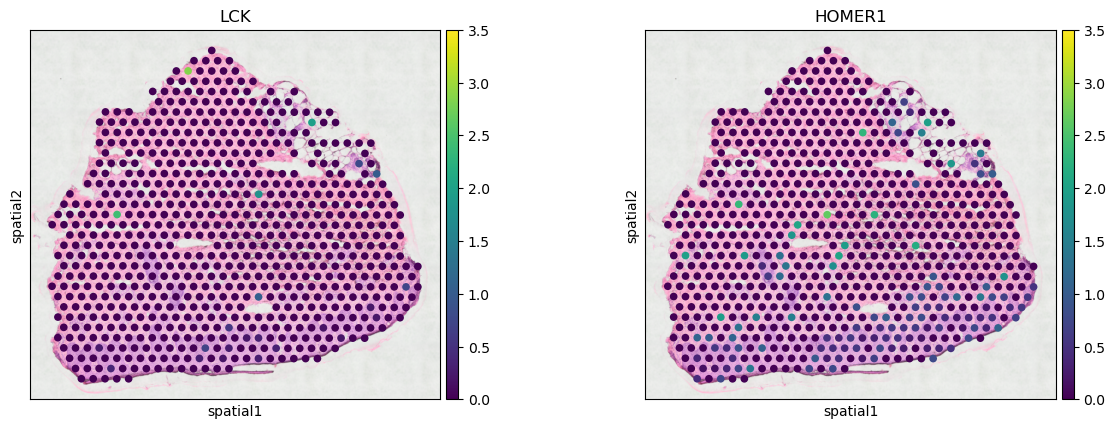

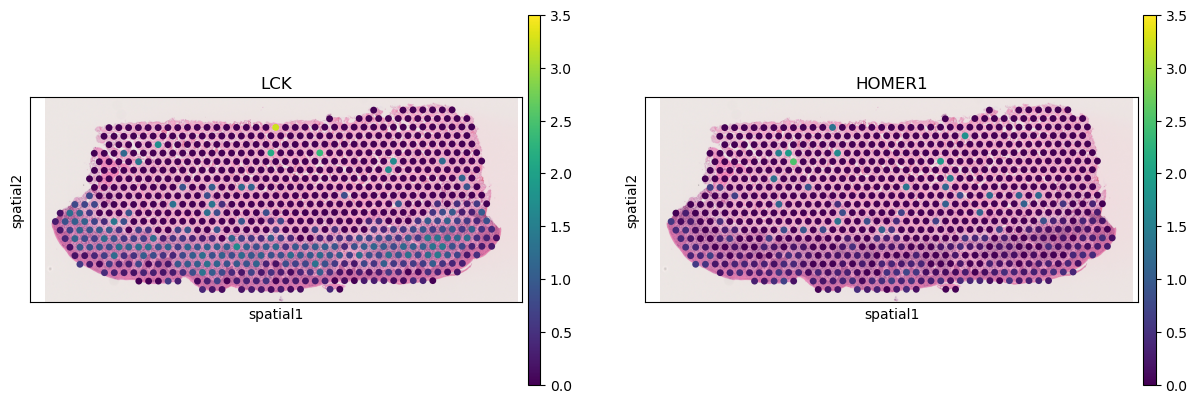

In [7]:
adata_filtered = adata_combined[adata_combined.obs["sample"].isin(["CTCL_6", "P15509_1004", "P16357_1028"]),].copy()
for sample in adata_filtered.obs["sample"].unique():
    sample_adata = adata_filtered[adata_filtered.obs["sample"] == sample,].copy()
    spatial_plot = sc.pl.spatial(sample_adata, color=["LCK", "HOMER1"], img_key="hires", library_id=sample, vmin=0, vmax=3.5, return_fig=True, show=True)
    spatial_plot.savefig(f"/lustre/groups/cbm01/workspace/martin.meinel/Safari/Classifier/figures/spatial_figure/HE/{sample}_{today}.svg", bbox_inches="tight")